Utilizaremos YOLOv8 para detectar automáticamente un robot y sacar de ahí sus coordenadas (punto central y bounding box) para pasárselos a SAM 3.

Iniciando pruebas comparativas...
Ultralytics 8.4.57  Python-3.11.15 torch-2.12.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]
Results saved to C:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\notebooks\runs\segment\predict-8
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
Evidencia guardada en ../docs/assets/m1/comparison\text_vs_point_vs_bbox.jpg


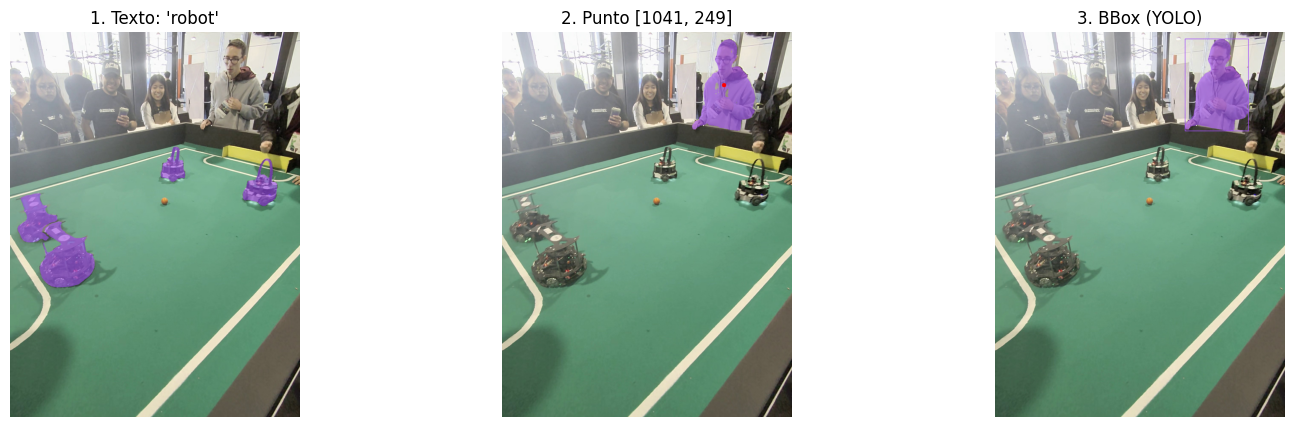

In [ ]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO, SAM
from ultralytics.models.sam import SAM3SemanticPredictor

# 1. Configurar rutas
sys.path.append(os.path.abspath("../src"))
from config import MODEL_PATH

# 2. Cargar imagen
img_path = "../docs/assets/m1/frames/frame_0050.jpg"
image = cv2.imread(img_path)

print("Iniciando pruebas comparativas...")

# --- PRUEBA 1: TEXTO ---
predictor_text = SAM3SemanticPredictor(overrides=dict(conf=0.25, task="segment", mode="predict", model=MODEL_PATH, device="cpu", verbose=False))
predictor_text.set_image(image)
res_text = predictor_text(text=["robot"])[0]
det_text = sv.Detections.from_ultralytics(res_text)

# --- OBTENER COORDENADAS CON YOLO ---
# Usamos un modelo ligero de YOLO para encontrar un objeto y extraer sus coordenadas
yolo = YOLO("yolov8n.pt")
res_yolo = yolo(image, verbose=False)[0]
det_yolo = sv.Detections.from_ultralytics(res_yolo)

# Tomamos el primer objeto detectado (clase 0 = persona/robot)
bbox = det_yolo.xyxy[0].tolist()
centro_x = int((bbox[0] + bbox[2]) / 2)
centro_y = int((bbox[1] + bbox[3]) / 2)
punto = [[centro_x, centro_y]]

# Cargar SAM genérico para Puntos y Bboxes
sam_model = SAM(MODEL_PATH)

# --- PRUEBA 2: PUNTO ---
res_point = sam_model.predict(source=image, points=punto, labels=[1], device="cpu", verbose=False)[0]
det_point = sv.Detections.from_ultralytics(res_point)

# --- PRUEBA 3: BOUNDING BOX ---
res_bbox = sam_model(image, bboxes=[bbox], device="cpu", verbose=False)[0]
det_bbox = sv.Detections.from_ultralytics(res_bbox)

# --- VISUALIZACIÓN LADO A LADO ---
mask_annotator = sv.MaskAnnotator(opacity=0.6)
box_annotator = sv.BoxAnnotator(thickness=2)

img_text = mask_annotator.annotate(scene=image.copy(), detections=det_text)

img_point = mask_annotator.annotate(scene=image.copy(), detections=det_point)
cv2.circle(img_point, (punto[0][0], punto[0][1]), 10, (0, 0, 255), -1) # Dibujamos el punto

img_bbox = mask_annotator.annotate(scene=image.copy(), detections=det_bbox)
img_bbox = box_annotator.annotate(scene=img_bbox, detections=det_bbox) # Dibujamos la caja

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(img_text, cv2.COLOR_BGR2RGB)); axes[0].set_title("1. Texto: 'robot'"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(img_point, cv2.COLOR_BGR2RGB)); axes[1].set_title(f"2. Punto {punto[0]}"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB)); axes[2].set_title("3. BBox (YOLO)"); axes[2].axis("off")

# Guardar evidencia
out_dir = "../docs/assets/m1/comparison"
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, "text_vs_point_vs_bbox.jpg")
plt.savefig(out_file, bbox_inches='tight')
print(f"Evidencia guardada en {out_file}")
plt.show()